In [30]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')

import scienceplots

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('science')
from analysis import Analysis
import nafflib

In [62]:
a = Analysis('data/resonance/dir_sc')
Qx_a = a.get_tunes(a.x[a.survivor_mask], a.px[a.survivor_mask], 'x')
Qy_a = a.get_tunes(a.y[a.survivor_mask], a.py[a.survivor_mask], 'y')
b = Analysis('data/resonance/ind_sc')
Qx_b = a.get_tunes(b.x[b.survivor_mask], b.px[b.survivor_mask], 'x')
Qy_b = a.get_tunes(b.y[b.survivor_mask], b.py[b.survivor_mask], 'y')

c = Analysis('data/resonance/dir_sc_kick_skew')
Qx_c = c.get_tunes(c.x[c.survivor_mask], c.px[c.survivor_mask], 'x')
Qy_c = c.get_tunes(c.y[c.survivor_mask], c.py[c.survivor_mask], 'y')
d = Analysis('data/resonance/ind_sc_kick_skew')
Qx_d = d.get_tunes(d.x[d.survivor_mask], d.px[d.survivor_mask], 'x')
Qy_d = d.get_tunes(d.y[d.survivor_mask], d.py[d.survivor_mask], 'y')

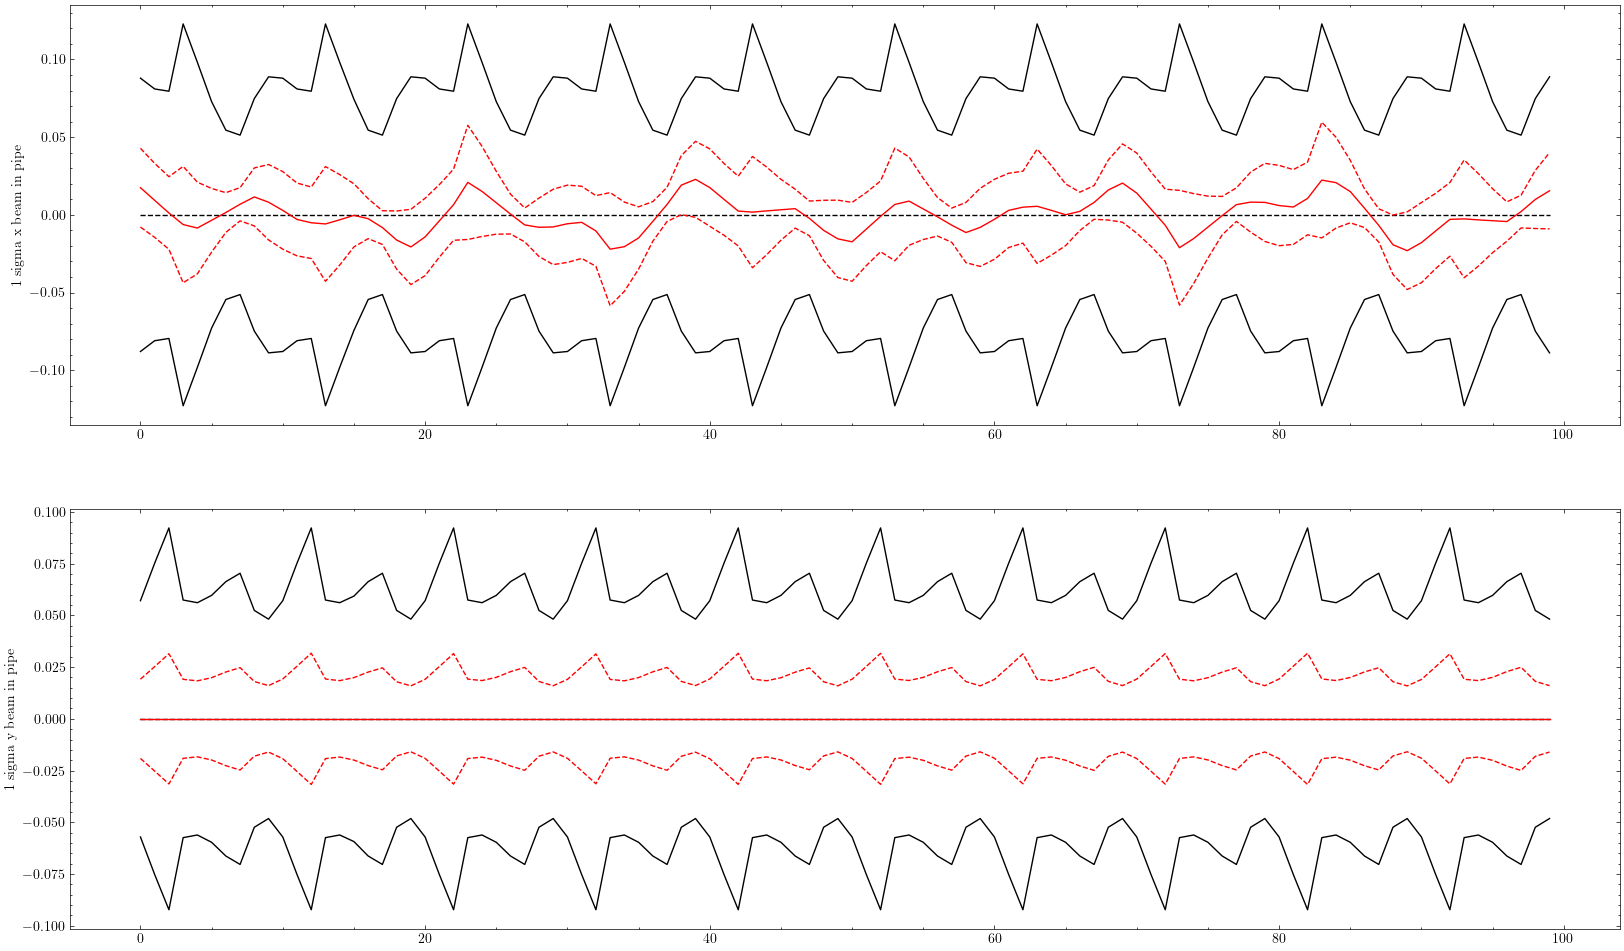

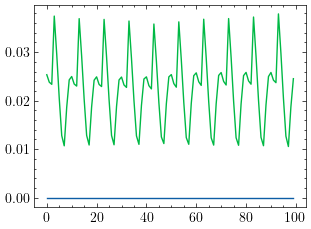

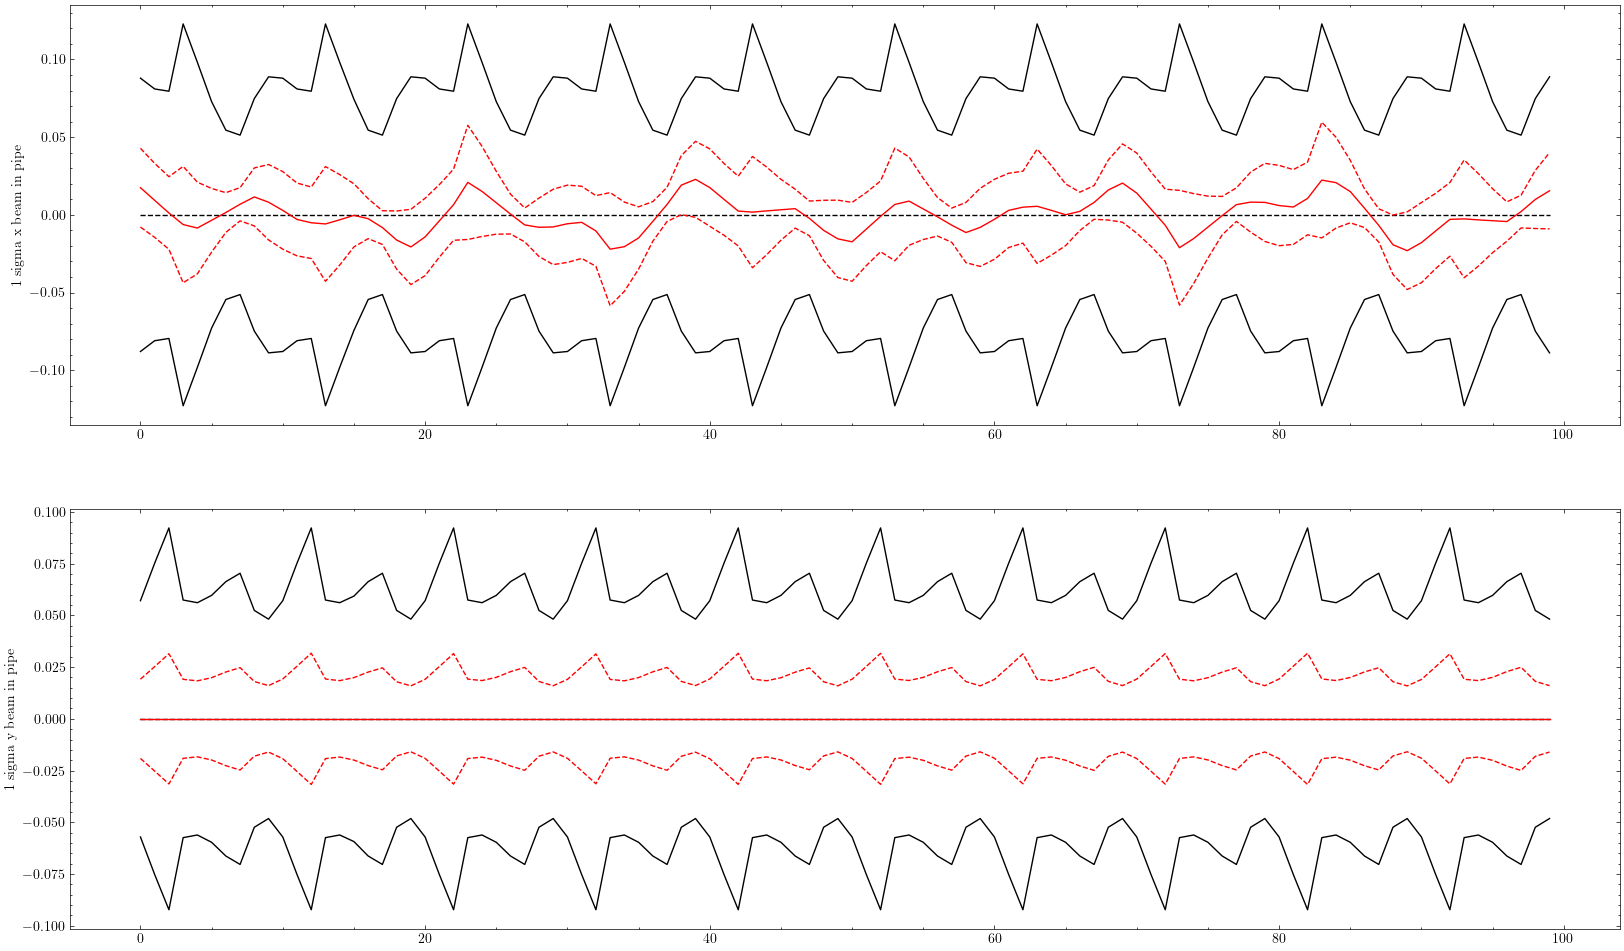

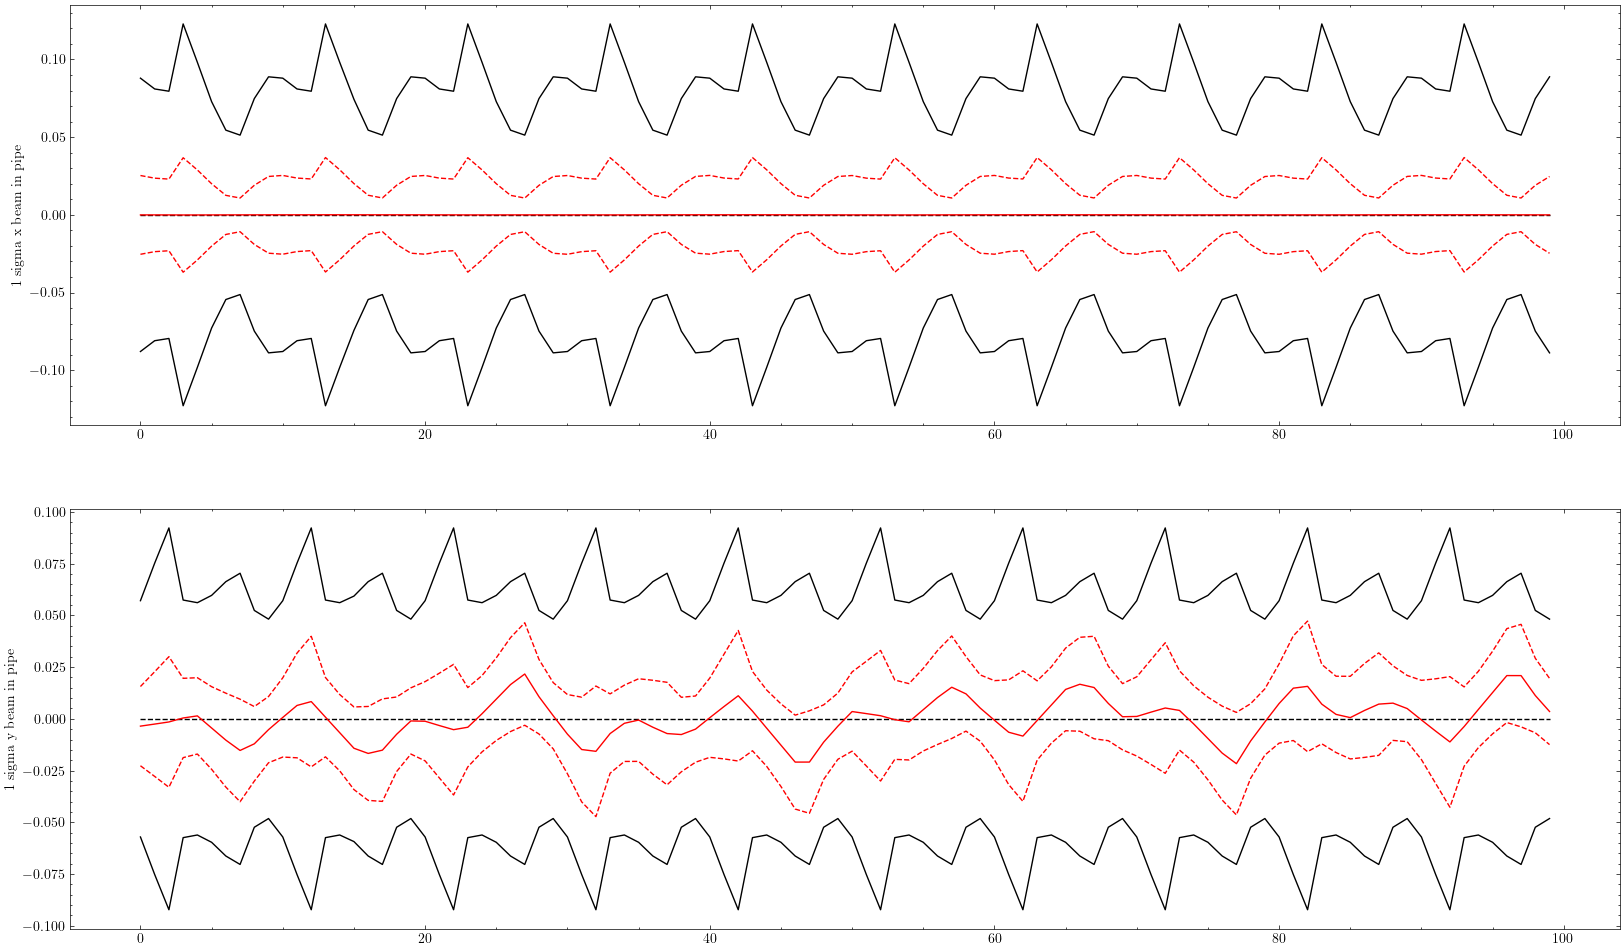

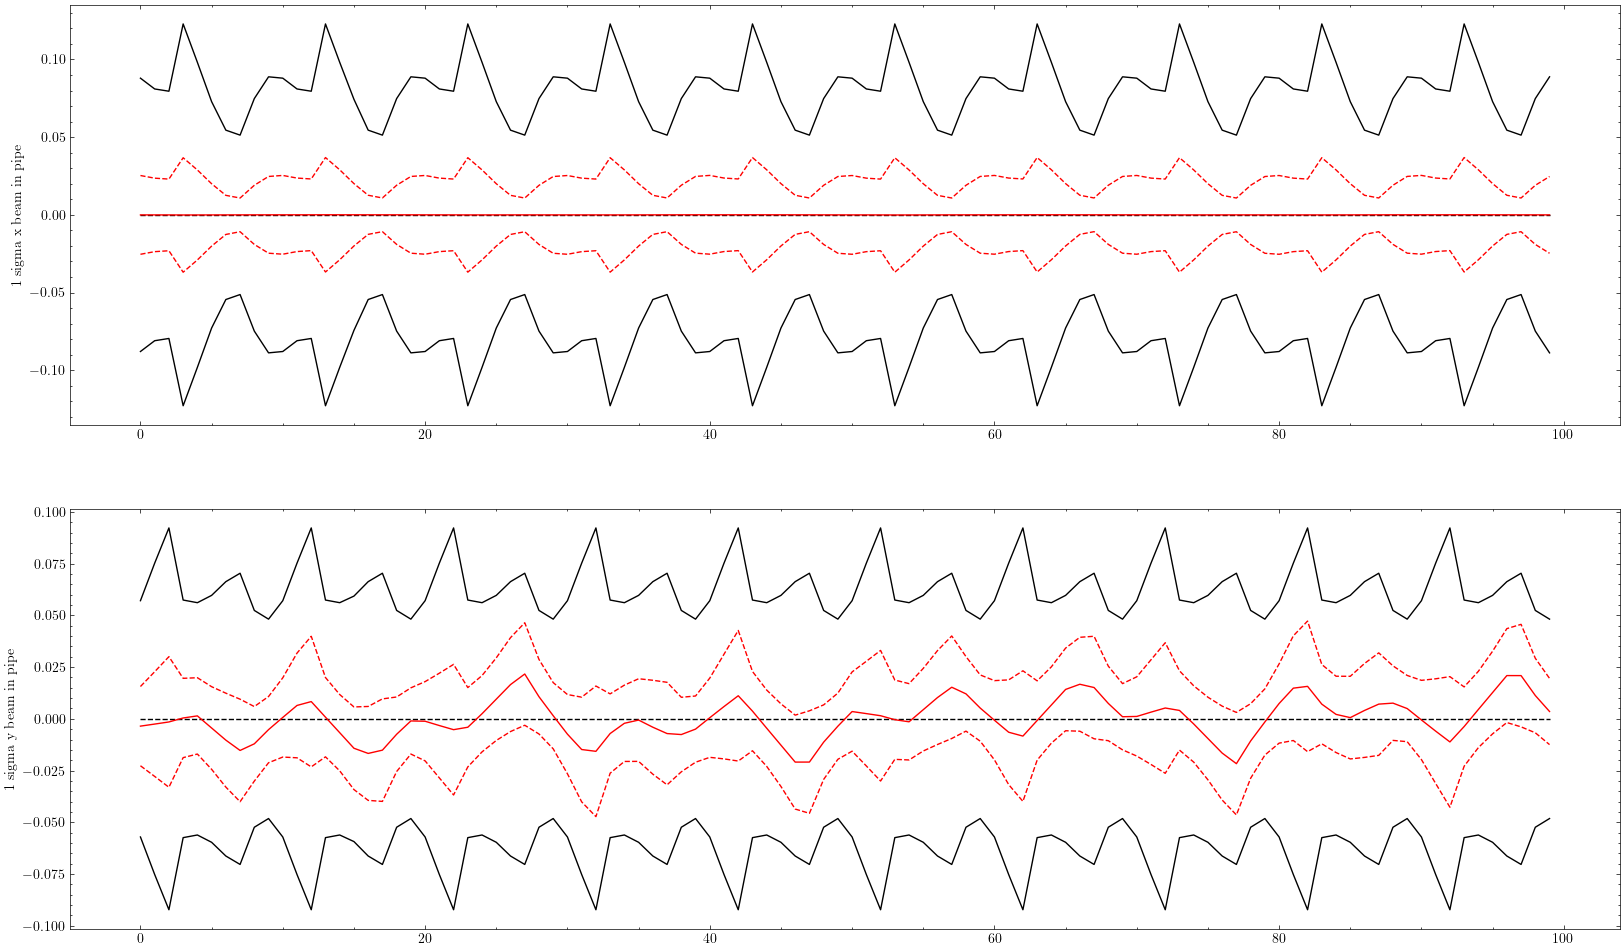

In [35]:
a.plot_field_in_pipe()
plt.plot(a.x_pipe)
plt.plot(a.sigma_x)
b.plot_field_in_pipe()
c.plot_field_in_pipe()
d.plot_field_in_pipe()

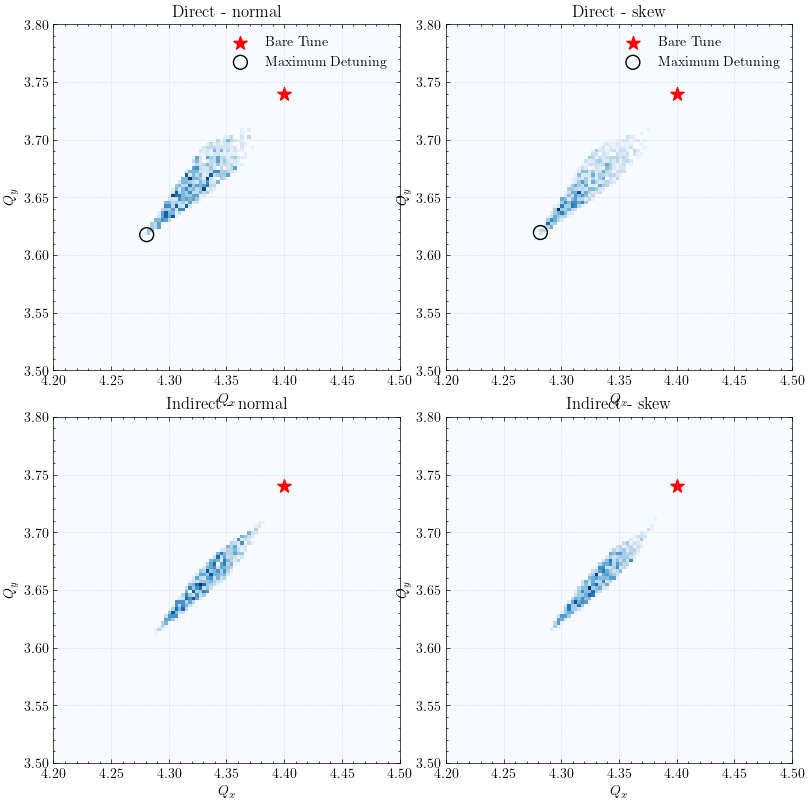

In [63]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
fig.subplots_adjust(wspace=0, hspace=0)
plt.tight_layout()

axs[0,0].hist2d(Qx_a, Qy_a, bins=100, cmap='Blues', range=[(4.2,4.5), (3.5, 3.8)])
axs[0,0].scatter(a.qx, a.qy, marker='*', s=100, c='r', label='Bare Tune')
axs[0,0].scatter(min(Qx_a), min(Qy_a), marker='o', facecolors='none', s=100, edgecolors='k', label='Maximum Detuning')
axs[0,0].set_xlabel(r"$Q_x$")
axs[0,0].set_ylabel(r"$Q_y$")
axs[0,0].set_title(f'Direct - normal')
axs[0,0].legend()
axs[0,0].set_aspect('equal')
axs[0,0].grid(True, linestyle=':', alpha=0.6)


axs[1,0].hist2d(Qx_b, Qy_b, bins=100, cmap='Blues', range=[(4.2,4.5), (3.5,3.8)])
axs[1,0].scatter(b.qx, b.qy, marker='*', s=100, c='r', label='Bare Tune')
axs[1,0].set_xlabel(r"$Q_x$")
axs[1,0].set_ylabel(r"$Q_y$")
axs[1,0].set_title(f'Indirect - normal')
axs[1,0].set_aspect('equal')
axs[1,0].grid(True, linestyle=':', alpha=0.6)

axs[0,1].hist2d(Qx_c, Qy_c, bins=100, cmap='Blues', range=[(4.2,4.5), (3.5,3.8)])
axs[0,1].scatter(c.qx, c.qy, marker='*', s=100, c='r', label='Bare Tune')
axs[0,1].scatter(min(Qx_c), min(Qy_c), marker='o', facecolors='none', s=100, edgecolors='k', label='Maximum Detuning')
axs[0,1].set_xlabel(r"$Q_x$")
axs[0,1].set_ylabel(r"$Q_y$")
axs[0,1].set_title(f'Direct - skew')
axs[0,1].legend()
axs[0,1].set_aspect('equal')
axs[0,1].grid(True, linestyle=':', alpha=0.6)


axs[1,1].hist2d(Qx_d, Qy_d, bins=100, cmap='Blues', range=[(4.2,4.5), (3.5,3.8)])
axs[1,1].scatter(d.qx, d.qy, marker='*', s=100, c='r', label='Bare Tune')
axs[1,1].set_xlabel(r"$Q_x$")
axs[1,1].set_ylabel(r"$Q_y$")
axs[1,1].set_title(f'Indirect - skew')
axs[1,1].set_aspect('equal')
axs[1,1].grid(True, linestyle=':', alpha=0.6)


fig.savefig('footprints.pdf')

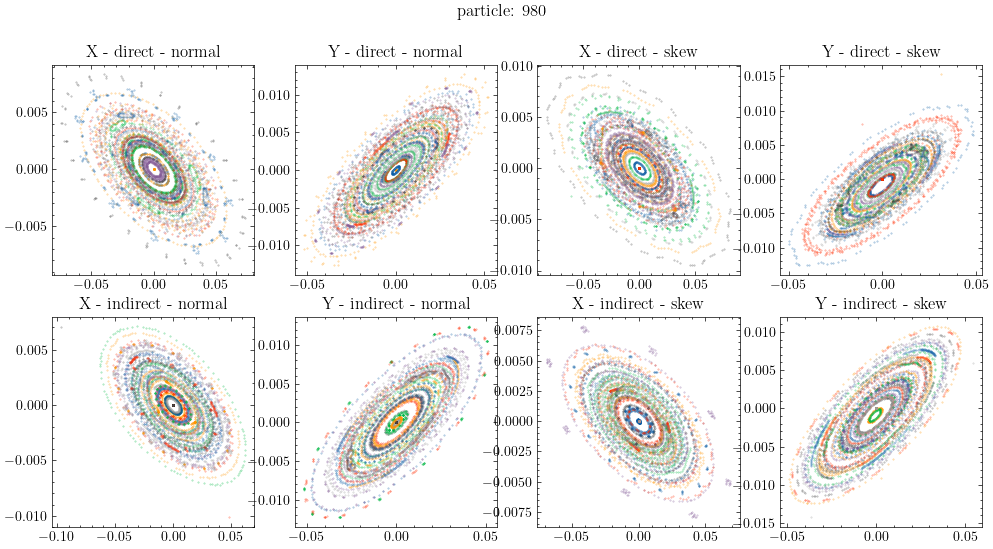

In [64]:
fig, axs = plt.subplots(2,4, figsize=(12,6))
for particle in range(0, a.n_particles, 20):
    time = turn*a.n_monitors
    axs[0,0].scatter(a.x[particle][::100], a.px[particle][::100], marker='.', s=0.5, alpha=0.5)
    axs[0,1].scatter(a.y[particle][::100], a.py[particle][::100], marker='.', s=0.5, alpha=0.5)
    axs[1,0].scatter(b.x[particle][::100], b.px[particle][::100], marker='.', s=0.5, alpha=0.5)
    axs[1,1].scatter(b.y[particle][::100], b.py[particle][::100], marker='.', s=0.5, alpha=0.5)

    axs[0,0].set_title('X - direct - normal')
    axs[0,1].set_title('Y - direct - normal')
    axs[1,0].set_title('X - indirect - normal')
    axs[1,1].set_title('Y - indirect - normal')

    axs[0,2].scatter(c.x[particle][::100], c.px[particle][::100], marker='.', s=0.5, alpha=0.5)
    axs[0,3].scatter(c.y[particle][::100], c.py[particle][::100], marker='.', s=0.5, alpha=0.5)
    axs[1,2].scatter(d.x[particle][::100], d.px[particle][::100], marker='.', s=0.5, alpha=0.5)
    axs[1,3].scatter(d.y[particle][::100], d.py[particle][::100], marker='.', s=0.5, alpha=0.5)

    axs[0,2].set_title('X - direct - skew')
    axs[0,3].set_title('Y - direct - skew')
    axs[1,2].set_title('X - indirect - skew')
    axs[1,3].set_title('Y - indirect - skew')
    fig.suptitle(f'particle: {particle}')

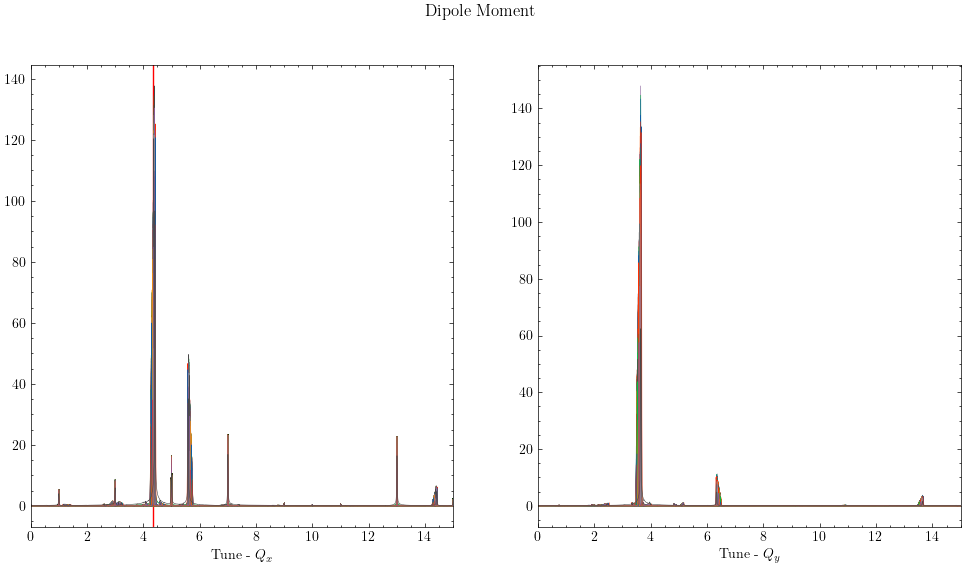

In [42]:
data=b

fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].set_xlim(0,15)#(4.1, 4.5)
ax[1].set_xlim(0,15)#(3.4, 3.7)
ax[0].axvline(x=4.333, color='red', label='Bare tune')
plt.legend()
fig.suptitle('Dipole Moment')
ax[0].set_xlabel('Tune - $Q_x$')
ax[1].set_xlabel('Tune - $Q_y$')
for x in data.x:#x = np.mean(c.x, axis=0)
    N = len(x)
    x = (x - np.mean(x))**1
    window = np.hanning(N)
    x = x * window
    fft_values = np.fft.rfft(x)
    frequencies = np.fft.rfftfreq(N) * 100
    amplitude = np.abs(fft_values)
    ax[0].plot(frequencies, amplitude, lw=0.4)
for y in data.y:#x = np.mean(c.x, axis=0)
    N = len(y)
    y = y - np.mean(y)
    window = np.hanning(N)
    y = y * window
    fft_values = np.fft.rfft(y)
    frequencies = np.fft.rfftfreq(N) * 100
    amplitude = np.abs(fft_values)
    ax[1].plot(frequencies, amplitude, lw=0.4)


# 91

In [6]:
a = Analysis('data/resonance/dir_sc_91')
Qx_a = a.get_tunes(a.x[a.survivor_mask], a.px[a.survivor_mask], 'x')
Qy_a = a.get_tunes(a.y[a.survivor_mask], a.py[a.survivor_mask], 'y')
b = Analysis('data/resonance/ind_sc_91')
Qx_b = a.get_tunes(b.x[b.survivor_mask], b.px[b.survivor_mask], 'x')
Qy_b = a.get_tunes(b.y[b.survivor_mask], b.py[b.survivor_mask], 'y')

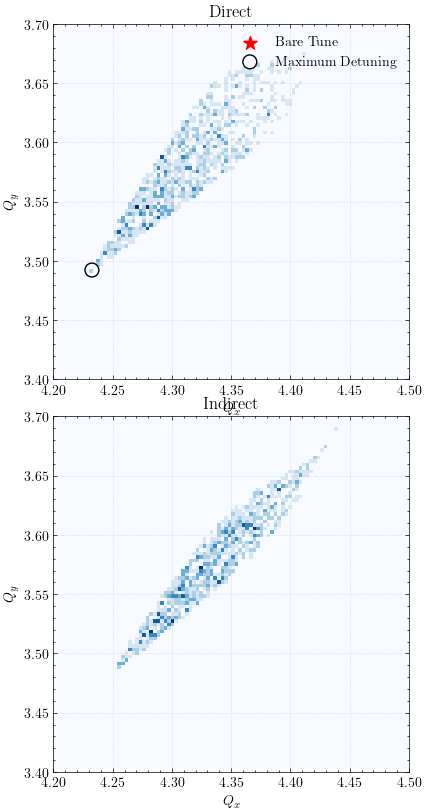

In [7]:
fig, axs = plt.subplots(2, figsize=(8, 8))
fig.subplots_adjust(wspace=0, hspace=0)
plt.tight_layout()

axs[0].hist2d(Qx_a, Qy_a, bins=100, cmap='Blues', range=[(4.2,4.5), (3.4, 3.7)])
axs[0].scatter(a.qx, a.qy, marker='*', s=100, c='r', label='Bare Tune')
axs[0].scatter(min(Qx_a), min(Qy_a), marker='o', facecolors='none', s=100, edgecolors='k', label='Maximum Detuning')
axs[0].set_xlabel(r"$Q_x$")
axs[0].set_ylabel(r"$Q_y$")
axs[0].set_title(f'Direct')
axs[0].legend()
axs[0].set_aspect('equal')
axs[0].grid(True, linestyle=':', alpha=0.6)


axs[1].hist2d(Qx_b, Qy_b, bins=100, cmap='Blues', range=[(4.2,4.5), (3.4,3.7)])
axs[1].scatter(b.qx, b.qy, marker='*', s=100, c='r', label='Bare Tune')
axs[1].set_xlabel(r"$Q_x$")
axs[1].set_ylabel(r"$Q_y$")
axs[1].set_title(f'Indirect')
axs[1].set_aspect('equal')
axs[1].grid(True, linestyle=':', alpha=0.6)